# Ejercicio 4 - Analisis exploratorio con DuckDB

Todas las consultas usan las vistas de `sql/00_vistas.sql`, `sql/01_zonas.sql` y `sql/02_vistas_analisis.sql` (`viajes`, `viajes_enriquecidos`, `viajes_validos`, `zonas`), que leen los Parquet al momento de consultar. Como no mencionan rutas ni anios, siguen funcionando al agregar 2024 y 2025.

**Flujo:** primero se ejecutan las consultas con `python scripts/run_sql.py ejercicio4`, que guarda cada resultado en `docs/resultados/ejercicio4/*.csv`. Este notebook lee esos resultados (unas pocas filas cada uno) y solo grafica; si falta un CSV, ejecuta la consulta en DuckDB. Asi las consultas pesadas sobre 30 millones de registros se ejecutan una sola vez y el notebook no compite por memoria.

Preguntas, justificacion e interpretacion: `docs/ejercicio4_analisis.md`. Las figuras se guardan en `docs/figuras/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # notebooks/ -> scripts/
from lab import conectar, ejecutar_sql, consulta, RAIZ_REPO

import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

def correr(archivo):
    """Ejecuta un .sql, muestra sus metadatos y tiempo, y devuelve el DataFrame."""
    meta, df, seg = ejecutar_sql(con, archivo)
    print(f"[{meta.get('id')}] {meta.get('titulo', '')}")
    for clave in ("pregunta", "objetivo", "fuente"):
        if clave in meta:
            print(f"  {clave}: {meta[clave]}")
    print(f"  tiempo: {seg:.3f} s | filas: {len(df)}")
    return df

con = conectar()
DIR_RES = RAIZ_REPO / "docs" / "resultados" / "ejercicio4"

def cargar(archivo):
    """Lee el CSV que genero scripts/run_sql.py para esa consulta.
    Si no existe, ejecuta la consulta en DuckDB."""
    csv = DIR_RES / (Path(archivo).stem + ".csv")
    if csv.exists():
        print(f"[{Path(archivo).stem}] leido de {csv.relative_to(RAIZ_REPO)}")
        return pd.read_csv(csv)
    return correr(archivo)

import matplotlib.pyplot as plt
import numpy as np

DIR_FIG = RAIZ_REPO / "docs" / "figuras"
DIR_FIG.mkdir(parents=True, exist_ok=True)
COLOR = {"yellow": "#E8A202", "green": "#2E8B57"}
DIAS = ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(DIR_FIG / f"{nombre}.png", bbox_inches="tight")
    plt.show()


## P1 - Volumen mensual por tipo de taxi

[4_01_viajes_por_mes] leido de docs/resultados/ejercicio4/4_01_viajes_por_mes.csv


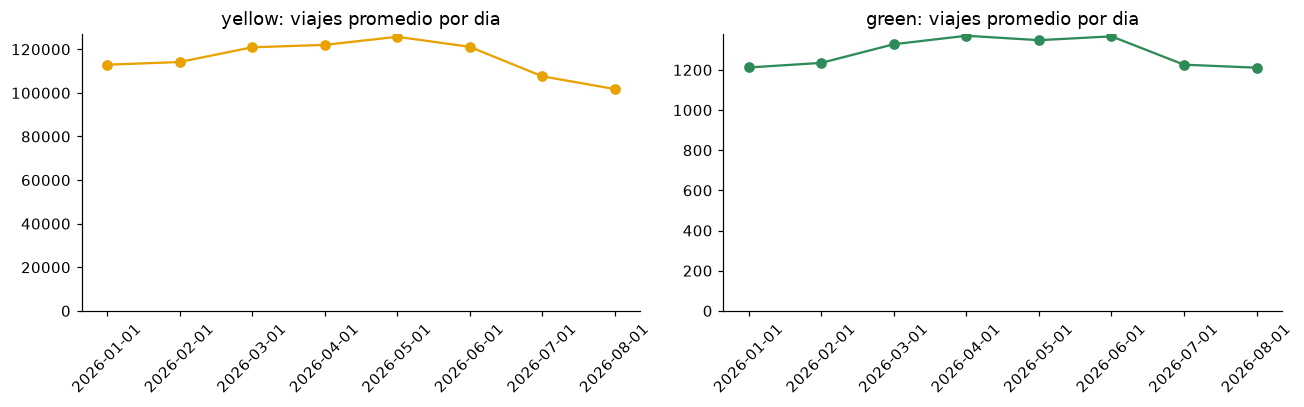

,mes,taxi,viajes,viajes_por_dia,pct_del_mes
0,2026-01-01,yellow,3500703,112926.0,98.94
1,2026-01-01,green,37567,1212.0,1.06
2,2026-02-01,yellow,3196364,114156.0,98.93
3,2026-02-01,green,34593,1235.0,1.07
4,2026-03-01,yellow,3748151,120908.0,98.91
5,2026-03-01,green,41154,1328.0,1.09
6,2026-04-01,yellow,3660483,122016.0,98.89
7,2026-04-01,green,41085,1370.0,1.11
8,2026-05-01,yellow,3897714,125733.0,98.94
9,2026-05-01,green,41794,1348.0,1.06


In [2]:
p1 = cargar("sql/ejercicio4/4_01_viajes_por_mes.sql")
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = p1[p1.taxi == taxi]
    eje.plot(d.mes, d.viajes_por_dia, marker="o", color=COLOR[taxi])
    eje.set_title(f"{taxi}: viajes promedio por dia")
    eje.set_ylim(bottom=0)
    eje.tick_params(axis="x", rotation=45)
guardar(fig, "p1_viajes_por_mes")
p1

## P2 - Demanda por hora y dia de la semana

Color = % de los viajes de ese tipo de taxi (escala propia por tipo).

[4_02_hora_dia_semana] leido de docs/resultados/ejercicio4/4_02_hora_dia_semana.csv


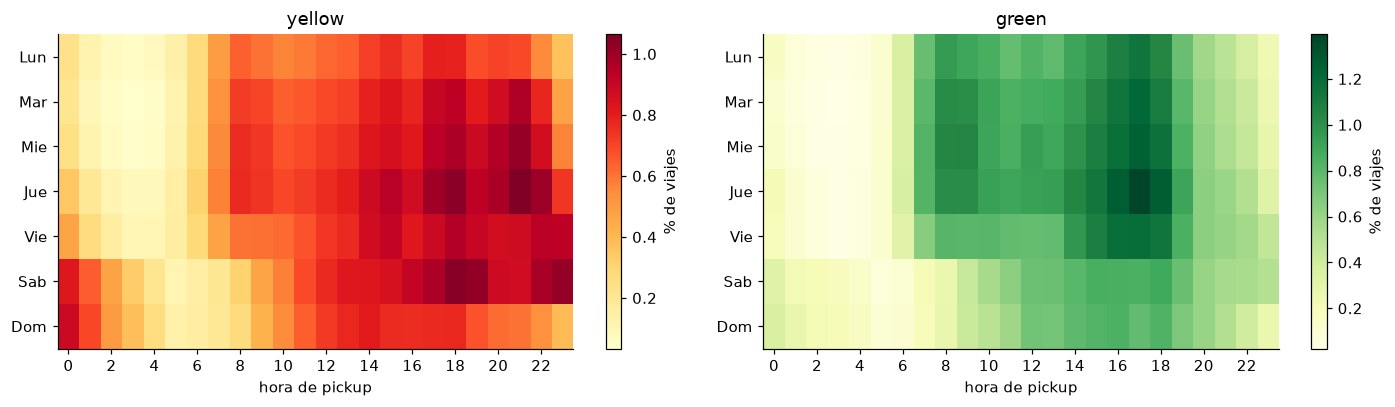

taxi
green     17
yellow    18
dtype: int64

In [3]:
p2 = cargar("sql/ejercicio4/4_02_hora_dia_semana.sql")
fig, ejes = plt.subplots(1, 2, figsize=(13, 3.8))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    m = p2[p2.taxi == taxi].pivot(index="dia_semana", columns="hora", values="pct_del_tipo")
    im = eje.imshow(m.values, aspect="auto", cmap="YlOrRd" if taxi == "yellow" else "YlGn")
    eje.set_yticks(range(7), DIAS)
    eje.set_xticks(range(0, 24, 2), range(0, 24, 2))
    eje.set_xlabel("hora de pickup")
    eje.set_title(taxi)
    fig.colorbar(im, ax=eje, label="% de viajes")
guardar(fig, "p2_hora_dia")
p2.groupby(["taxi", "hora"]).viajes.sum().unstack(0).idxmax()   # hora pico por tipo

## P3 - Caracteristicas de los viajes

Linea = p10 a p90, caja = p25 a p75, punto = mediana.

[4_03_caracteristicas_viaje] leido de docs/resultados/ejercicio4/4_03_caracteristicas_viaje.csv


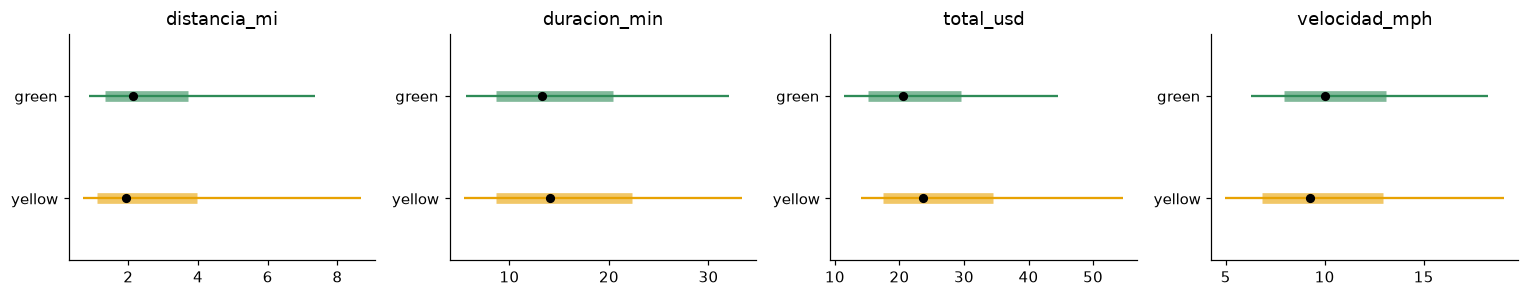

,variable,taxi,p10,p25,mediana,promedio,p75,p90,p99,maximo
0,distancia_mi,yellow,0.69,1.10,1.94,3.51,3.96,8.69,19.57,99.93
1,distancia_mi,green,0.86,1.32,2.13,3.31,3.72,7.37,17.68,94.10
2,duracion_min,yellow,5.39,8.62,14.12,17.69,22.27,33.40,71.38,360.00
3,duracion_min,green,5.67,8.66,13.23,17.06,20.38,32.03,73.98,359.33
4,total_usd,yellow,13.97,17.49,23.62,30.26,34.47,54.67,105.31,1065.72
5,total_usd,green,11.47,15.07,20.51,25.37,29.56,44.57,95.60,625.10
6,velocidad_mph,yellow,4.98,6.83,9.28,10.88,12.93,19.06,34.31,80.00
7,velocidad_mph,green,6.27,7.96,10.04,11.37,13.09,18.23,31.71,80.00


In [4]:
p3 = cargar("sql/ejercicio4/4_03_caracteristicas_viaje.sql")
variables = p3.variable.unique()
fig, ejes = plt.subplots(1, len(variables), figsize=(14, 2.8))
for eje, var in zip(ejes, variables):
    d = p3[p3.variable == var].reset_index(drop=True)
    for i, r in d.iterrows():
        c = COLOR[r.taxi]
        eje.hlines(i, r.p10, r.p90, color=c, lw=1.5)
        eje.hlines(i, r.p25, r.p75, color=c, lw=7, alpha=.6)
        eje.plot(r.mediana, i, "o", color="black", ms=5)
    eje.set_yticks(range(len(d)), d.taxi)
    eje.set_ylim(-0.6, len(d) - 0.4)
    eje.set_title(var)
guardar(fig, "p3_caracteristicas")
p3

## P4 - Comparacion general amarillos vs. verdes

In [5]:
p4 = cargar("sql/ejercicio4/4_04_resumen_por_tipo.sql")
p4.set_index("taxi").T

[4_04_resumen_por_tipo] leido de docs/resultados/ejercicio4/4_04_resumen_por_tipo.csv


taxi,yellow,green
viajes,28127474.00,312777.00
pct_viajes,98.90,1.10
distancia_prom_mi,3.51,3.31
duracion_mediana_min,14.10,13.20
total_prom_usd,30.26,25.37
usd_por_milla_prom,34.46,20.53
pasajeros_prom,1.25,1.32
pct_tarjeta,65.30,76.80
pct_aeropuerto,9.74,0.29
pct_cargo_cbd,72.40,8.50


## P5 - Origen por borough

[4_05_viajes_por_borough] leido de docs/resultados/ejercicio4/4_05_viajes_por_borough.csv


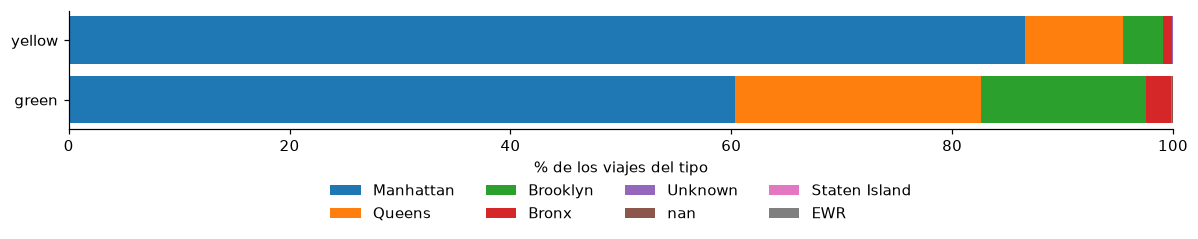

borough_origen,Manhattan,Queens,Brooklyn,Bronx,Unknown,NaN,Staten Island,EWR
taxi,,,,,,,,
green,60.32,22.30,14.97,2.27,0.08,0.05,0.02,0.0
yellow,86.63,8.86,3.61,0.77,0.10,0.02,0.01,0.0


In [6]:
p5 = cargar("sql/ejercicio4/4_05_viajes_por_borough.sql")
m = p5.pivot(index="taxi", columns="borough_origen", values="pct_del_tipo").fillna(0)
m = m[m.sum().sort_values(ascending=False).index]
fig, eje = plt.subplots(figsize=(11, 2.6))
izq = np.zeros(len(m))
for col in m.columns:
    eje.barh(m.index, m[col], left=izq, label=col)
    izq += m[col].values
eje.set_xlabel("% de los viajes del tipo")
eje.legend(ncol=4, bbox_to_anchor=(0.5, -0.35), loc="upper center", frameon=False)
guardar(fig, "p5_borough")
m.round(2)

## P6 - Metodo de pago y propina registrada

[4_06_metodo_pago] leido de docs/resultados/ejercicio4/4_06_metodo_pago.csv


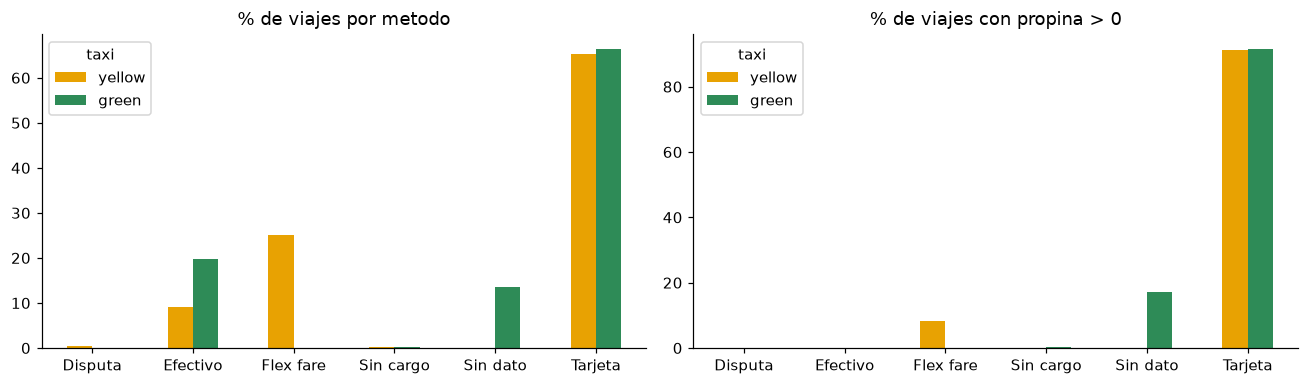

,taxi,payment_type,metodo_pago,viajes,pct_del_tipo,total_prom_usd,pct_con_propina,propina_mediana_pct
0,yellow,1.0,Tarjeta,18377834,65.34,30.04,91.1,26.4
1,yellow,0.0,Flex fare,7033453,25.01,32.44,8.3,0.0
2,yellow,2.0,Efectivo,2544110,9.04,26.04,0.0,0.0
3,yellow,4.0,Disputa,117357,0.42,28.86,0.0,0.0
4,yellow,3.0,Sin cargo,54720,0.19,24.50,0.0,0.0
5,green,1.0,Tarjeta,207581,66.37,25.60,91.5,23.6
6,green,2.0,Efectivo,61702,19.73,20.81,0.0,0.0
7,green,NaN,Sin dato,42664,13.64,30.99,17.3,0.0
8,green,3.0,Sin cargo,587,0.19,18.12,0.3,0.0
9,green,4.0,Disputa,243,0.08,19.96,0.0,0.0


In [7]:
p6 = cargar("sql/ejercicio4/4_06_metodo_pago.sql")
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
for eje, col, titulo in [(ejes[0], "pct_del_tipo", "% de viajes por metodo"),
                         (ejes[1], "pct_con_propina", "% de viajes con propina > 0")]:
    m = p6.pivot(index="metodo_pago", columns="taxi", values=col).reindex(columns=["yellow", "green"])
    m.plot.bar(ax=eje, color=[COLOR["yellow"], COLOR["green"]], rot=0)
    eje.set_title(titulo); eje.set_xlabel("")
guardar(fig, "p6_pago")
p6

## P7 - Porcentaje de propina (pagos con tarjeta)

[4_07_distribucion_propina] leido de docs/resultados/ejercicio4/4_07_distribucion_propina.csv


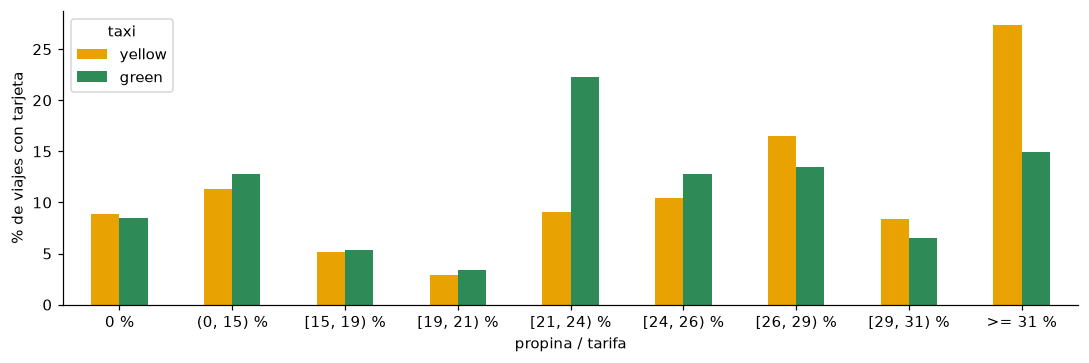

taxi,yellow,green
rango_propina,,
0 %,8.88,8.49
"(0, 15) %",11.32,12.77
"[15, 19) %",5.11,5.39
"[19, 21) %",2.90,3.39
"[21, 24) %",9.06,22.30
"[24, 26) %",10.43,12.79
"[26, 29) %",16.53,13.48
"[29, 31) %",8.40,6.49
>= 31 %,27.37,14.91


In [8]:
p7 = cargar("sql/ejercicio4/4_07_distribucion_propina.sql")
orden = p7.sort_values("orden").rango_propina.unique()
m = p7.pivot(index="rango_propina", columns="taxi", values="pct_del_tipo").reindex(orden)
m = m.reindex(columns=[c for c in ["yellow", "green"] if c in m.columns])
fig, eje = plt.subplots(figsize=(10, 3.4))
m.plot.bar(ax=eje, color=[COLOR[c] for c in m.columns], rot=0)
eje.set_ylabel("% de viajes con tarjeta"); eje.set_xlabel("propina / tarifa")
guardar(fig, "p7_propina")
m

## P8 - Distribucion del monto total

[4_08_histograma_total] leido de docs/resultados/ejercicio4/4_08_histograma_total.csv


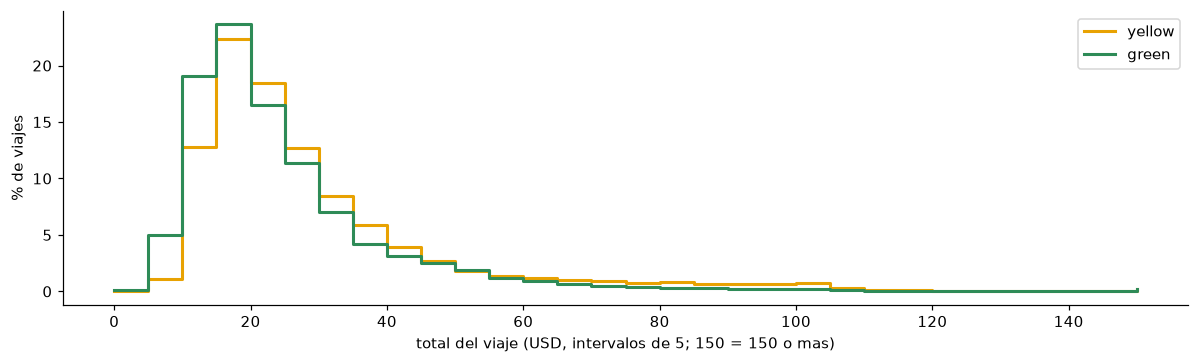

In [9]:
p8 = cargar("sql/ejercicio4/4_08_histograma_total.sql")
fig, eje = plt.subplots(figsize=(11, 3.4))
for taxi in ["yellow", "green"]:
    d = p8[p8.taxi == taxi]
    eje.step(d.desde_usd, d.pct_del_tipo, where="post", color=COLOR[taxi], label=taxi, lw=2)
eje.set_xlabel("total del viaje (USD, intervalos de 5; 150 = 150 o mas)")
eje.set_ylabel("% de viajes"); eje.legend()
guardar(fig, "p8_histograma_total")

## P9 - Registros atipicos o inconsistentes por regla

[4_09_impacto_reglas_calidad] leido de docs/resultados/ejercicio4/4_09_impacto_reglas_calidad.csv


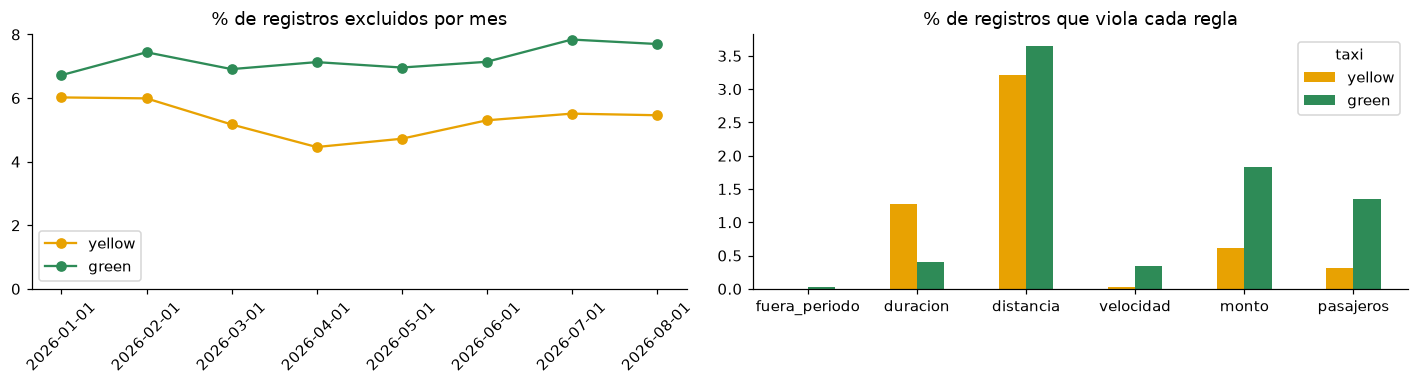

,fuera_periodo,duracion,distancia,velocidad,monto,pasajeros
taxi,,,,,,
green,0.029,0.397,3.644,0.344,1.838,1.343
yellow,0.000,1.276,3.210,0.027,0.607,0.308


In [10]:
p9 = cargar("sql/ejercicio4/4_09_impacto_reglas_calidad.sql")
reglas = ["fuera_periodo", "duracion", "distancia", "velocidad", "monto", "pasajeros"]
fig, ejes = plt.subplots(1, 2, figsize=(13, 3.6))
for taxi in ["yellow", "green"]:
    d = p9[p9.taxi == taxi]
    ejes[0].plot(d.mes_archivo, d.pct_excluido, marker="o", color=COLOR[taxi], label=taxi)
ejes[0].set_title("% de registros excluidos por mes"); ejes[0].legend()
ejes[0].tick_params(axis="x", rotation=45); ejes[0].set_ylim(bottom=0)
tot = p9.groupby("taxi")[reglas + ["registros"]].sum()
pct_regla = tot[reglas].div(tot.registros, axis=0) * 100
pct_regla.T[["yellow", "green"]].plot.bar(ax=ejes[1], color=[COLOR["yellow"], COLOR["green"]], rot=0)
ejes[1].set_title("% de registros que viola cada regla")
guardar(fig, "p9_calidad")
pct_regla.round(3)

## P10 - Atipicos de costo por milla (IQR)

In [11]:
cargar("sql/ejercicio4/4_10_atipicos_tarifa_milla.sql")

[4_10_atipicos_tarifa_milla] leido de docs/resultados/ejercicio4/4_10_atipicos_tarifa_milla.csv


,taxi,q1,q3,limite_inf,limite_sup,viajes,atipicos_altos,atipicos_bajos,distancia_mediana_atipicos_altos,pct_tarifa_especial_en_altos
0,yellow,5.73,9.95,-0.59,16.27,28127474,1622681,0,0.60,12.0
1,green,5.42,8.20,1.23,12.39,312777,16589,24181,0.52,27.7


## P11 - Propina como % del total antes de propina

Solo pagos con tarjeta del proveedor 2. Las lineas punteadas marcan los porcentajes que sugiere la pantalla del taxi.

[4_11_propina_sobre_total] leido de docs/resultados/ejercicio4/4_11_propina_sobre_total.csv


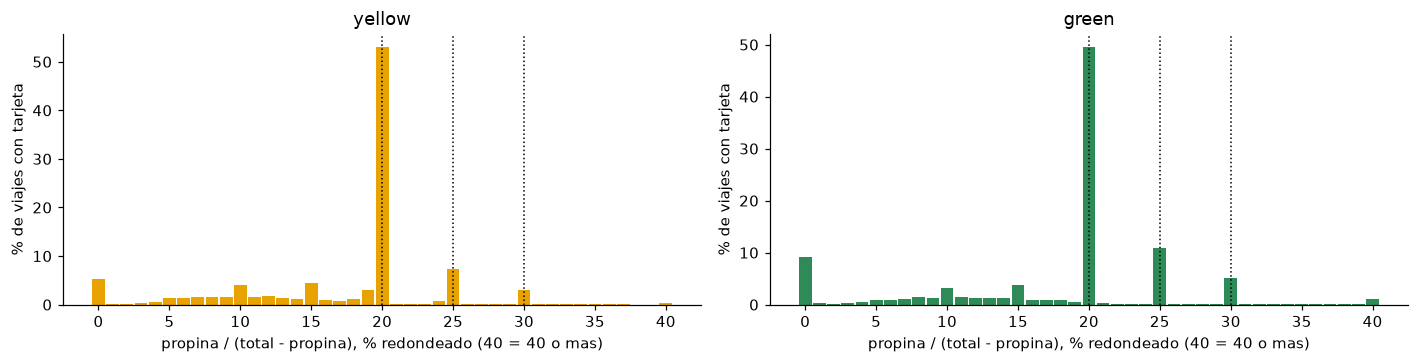

,taxi,pct_propina_sobre_total,viajes,pct_del_tipo
20,yellow,20.0,7662775,53.03
61,green,20.0,94170,49.54
66,green,25.0,20692,10.88
41,green,0.0,17500,9.21
25,yellow,25.0,1063756,7.36
0,yellow,0.0,774618,5.36
71,green,30.0,9689,5.10
15,yellow,15.0,642813,4.45
10,yellow,10.0,591198,4.09
56,green,15.0,7159,3.77


In [12]:
p11 = cargar("sql/ejercicio4/4_11_propina_sobre_total.sql")
fig, ejes = plt.subplots(1, 2, figsize=(13, 3.4))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = p11[p11.taxi == taxi]
    eje.bar(d.pct_propina_sobre_total, d.pct_del_tipo, color=COLOR[taxi], width=0.9)
    for x in (20, 25, 30):
        eje.axvline(x, color="black", ls=":", lw=1)
    eje.set_title(taxi); eje.set_xlabel("propina / (total - propina), % redondeado (40 = 40 o mas)")
    eje.set_ylabel("% de viajes con tarjeta")
guardar(fig, "p11_propina_sobre_total")
p11.sort_values("pct_del_tipo", ascending=False).groupby("taxi").head(5)